## **Importing necessary libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## **Loading Data**
**Load raw data csv file.**

In [2]:
import os
for dirname, _, filenames in os.walk('./data/raw/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./data/raw/financial_loan.csv


In [3]:
df = pd.read_csv("./data/raw/financial_loan.csv")

In [4]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade              38576 non-null  object 
 15  te

## **Data Cleaning**

### **Missing Values**

In [6]:
missing_values_count = df.isnull().sum()
print("Count of missing values in each column:")
print(missing_values_count)

Count of missing values in each column:
id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1438
grade                       0
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
dtype: int64


In [7]:
# Replacing na values in emp_title with N/A
df["emp_title"].fillna("N/A", inplace = True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_20420\2061428644.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["emp_title"].fillna("N/A", inplace = True)


### **Duplicate**

In [8]:
duplicates = df[df.duplicated()]
num_duplicates = duplicates.shape[0]

if num_duplicates == 0:
    print("There are no duplicates")
else:
    print("There are", num_duplicates, "duplicates.")

There are no duplicates


### **Clean specific properties**

Change data values of **emp_length**

In [9]:
# Check values
print(df['emp_length'].unique())

['< 1 year' '9 years' '4 years' '10+ years' '3 years' '5 years' '1 year'
 '6 years' '2 years' '7 years' '8 years']


In [10]:
def convert_emp_length(x):
    if pd.isnull(x):
        return np.nan
    # If value is "< 1 year" change to 0
    elif '<' in x:
        return 0
    # If value is "> 10 years" change to 10
    elif '10+' in x:
        return 10
    # If value is "n years" change to only n
    else:
        return int(x.split()[0])

df['emp_length'] = df['emp_length'].apply(convert_emp_length)

Change data values of **purpose**

In [11]:
# Check values
print(df['purpose'].unique())

['car' 'credit card' 'Debt consolidation' 'educational' 'home improvement'
 'house' 'major purchase' 'medical' 'moving' 'other' 'renewable_energy'
 'small business' 'vacation' 'wedding']


In [12]:
# Change values from lower string to title string and dont have character "_"
df['purpose'] = df['purpose'].str.title().str.replace('_', ' ')

Change data values of **term**

In [13]:
# Change data values of term
print(df['term'].unique())

[' 60 months' ' 36 months']


In [14]:
def convert_term(x):
    if pd.isnull(x):
        return np.nan
    # Change value from " 60 months" to only 60 (months)
    else:
        return int(x.split()[0])

df['term'] = df['term'].str.strip().apply(convert_term)

In [15]:
df['issue_date'].isna()

0        False
1        False
2        False
3        False
4        False
         ...  
38571    False
38572    False
38573    False
38574    False
38575    False
Name: issue_date, Length: 38576, dtype: bool

### **Change data types**

In [16]:
df.dtypes

id                         int64
address_state             object
application_type          object
emp_length                 int64
emp_title                 object
grade                     object
home_ownership            object
issue_date                object
last_credit_pull_date     object
last_payment_date         object
loan_status               object
next_payment_date         object
member_id                  int64
purpose                   object
sub_grade                 object
term                       int64
verification_status       object
annual_income            float64
dti                      float64
installment              float64
int_rate                 float64
loan_amount                int64
total_acc                  int64
total_payment              int64
dtype: object

In [ ]:
# Change to datetime type
date_cols = ['issue_date', 'last_credit_pull_date', 'last_payment_date', 'next_payment_date']
for col in date_cols:
    df[col] = df[col].str.replace('-', '/')
    df[col] = pd.to_datetime(df[col], format='%d/%m/%Y')

In [35]:
#to float
df['loan_amount'] = df['loan_amount'].astype(float)

df['total_payment'] = df['total_payment'].astype(float)

### **Storage transformed data into csv file**

In [ ]:
df.to_csv('./data/transformed/cleaned_bank_loan_data.csv', index=False)

## **Exploratory Data Analysis (EDA)**

Load transformed data

In [2]:
data = pd.read_csv('./data/transformed/cleaned_bank_loan_data.csv')
data.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,0,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60,Source Verified,30000.0,0.0100,59.83,0.1527,2500.0,4,1009.0
1,1072053,CA,INDIVIDUAL,9,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36,Source Verified,48000.0,0.0535,109.43,0.1864,3000.0,4,3939.0
2,1069243,CA,INDIVIDUAL,4,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36,Not Verified,50000.0,0.2088,421.65,0.1596,12000.0,11,3522.0
3,1041756,TX,INDIVIDUAL,0,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60,Source Verified,42000.0,0.0540,97.06,0.1065,4500.0,9,4911.0
4,1068350,IL,INDIVIDUAL,10,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36,Verified,83000.0,0.0231,106.53,0.0603,3500.0,28,3835.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  int64  
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade              38576 non-null  object 
 15  te

In [3]:
data['issue_date'] = pd.to_datetime(data['issue_date'], format='%Y-%m-%d')
data['issue_month'] = data['issue_date'].dt.month_name()
data.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment,issue_month
0,1077430,GA,INDIVIDUAL,0,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,60,Source Verified,30000.0,0.0100,59.83,0.1527,2500.0,4,1009.0,February
1,1072053,CA,INDIVIDUAL,9,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,36,Source Verified,48000.0,0.0535,109.43,0.1864,3000.0,4,3939.0,January
2,1069243,CA,INDIVIDUAL,4,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,36,Not Verified,50000.0,0.2088,421.65,0.1596,12000.0,11,3522.0,January
3,1041756,TX,INDIVIDUAL,0,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,60,Source Verified,42000.0,0.0540,97.06,0.1065,4500.0,9,4911.0,February
4,1068350,IL,INDIVIDUAL,10,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,36,Verified,83000.0,0.0231,106.53,0.0603,3500.0,28,3835.0,January


#### **Overview by Month: Total Loan Applications, Total Funded Amount and Total Received Amount**

In [31]:
monthly_data = data.groupby(by='issue_month', as_index = False).agg({'loan_amount' : 'sum',
                                     'total_payment':'sum', 'id':'count'
                                     })
monthly_data

,issue_month,loan_amount,total_payment,id
0,April,29800800.0,32495533.0,2755
1,August,38149600.0,42682218.0,3441
2,December,53981425.0,58074380.0,4314
3,February,24647825.0,27717745.0,2279
4,January,25031650.0,27578836.0,2332
5,July,35813900.0,38827220.0,3366
6,June,34161475.0,36164533.0,3184
7,March,28875700.0,32264400.0,2627
8,May,31738350.0,33750523.0,2911
9,November,47754825.0,50132030.0,4035


In [32]:
def convert_to_million(x):
    return round(x/1000000,2)
monthly_data['loan_amount'] = monthly_data['loan_amount'].apply(convert_to_million)
monthly_data['total_payment'] = monthly_data['total_payment'].apply(convert_to_million)
monthly_data

,issue_month,loan_amount,total_payment,id
0,April,29.80,32.50,2755
1,August,38.15,42.68,3441
2,December,53.98,58.07,4314
3,February,24.65,27.72,2279
4,January,25.03,27.58,2332
5,July,35.81,38.83,3366
6,June,34.16,36.16,3184
7,March,28.88,32.26,2627
8,May,31.74,33.75,2911
9,November,47.75,50.13,4035


In [33]:
month_dict = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
monthly_data.sort_values('issue_month' , key = lambda x : x.apply(lambda y : month_dict[y]) , inplace = True)

c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: us

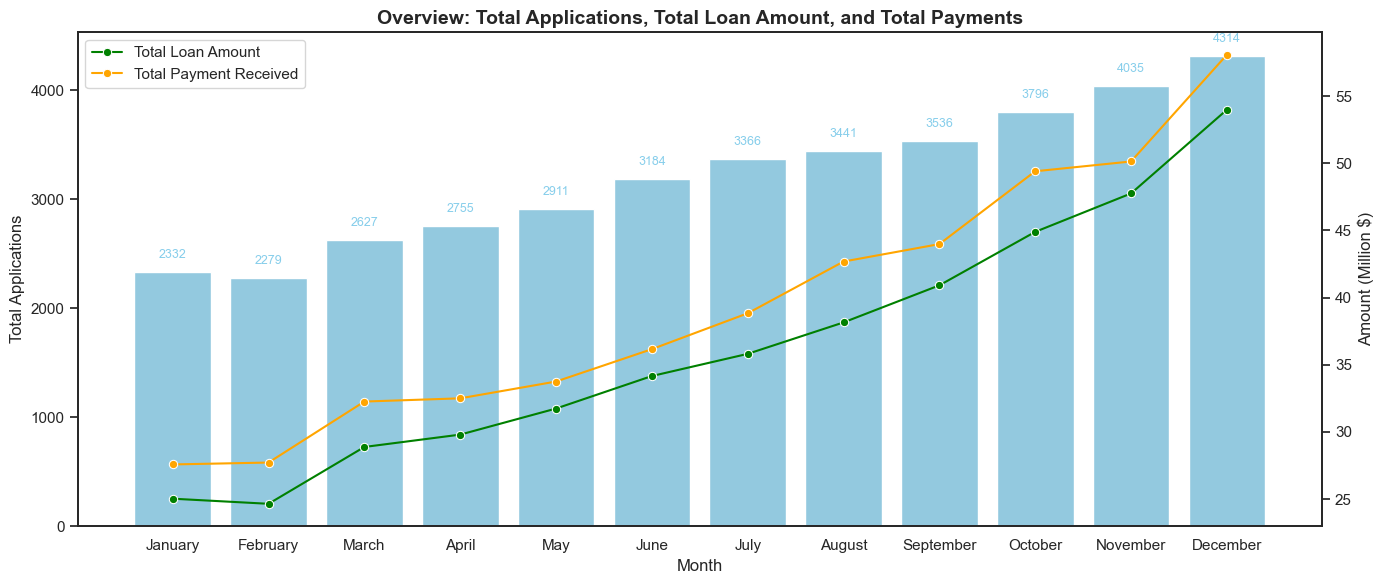

In [34]:
# Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar plot for total applications
sns.barplot(data=monthly_data, x='issue_month', y='id', color='skyblue', ax=ax1)
ax1.set_ylabel('Total Applications', fontsize=12)
ax1.set_xlabel('Month', fontsize=12)
ax1.tick_params(axis='y')
ax1.set_title('Overview: Total Applications, Total Loan Amount, and Total Payments', fontsize=14, fontweight='bold')

# Add values on top of bars
for i, v in enumerate(monthly_data['id']):
    ax1.text(i, v + 100, str(v), ha='center', va='bottom', fontsize=9, color='skyblue')

# Create a second y-axis
ax2 = ax1.twinx()

# Line plots for loan amount and total payment
sns.lineplot(data=monthly_data, x='issue_month', y='loan_amount', marker='o', label='Total Loan Amount', color='green', ax=ax2)
sns.lineplot(data=monthly_data, x='issue_month', y='total_payment', marker='o', label='Total Payment Received', color='orange', ax=ax2)
ax2.set_ylabel('Amount (Million $)', fontsize=12)
ax2.tick_params(axis='y')

# Add legends
ax2.legend(loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### **Conclusion**
1. **Peak Loan Activity**
- **December** had the highest number of applications (4,314), total loan amount (~$53.9M), and total payments (~$58M).
- **Insight**: Strong demand at year-end, likely due to holiday-related expenses.

2. **Low Activity Period**
- **January** and **February** had the lowest number of applications and loan amounts.
- **Insight**: Early-year dip; potential for promotional campaigns during this period.

3. **Healthy Loan Returns**
- In every month, **total payments > loan amounts**, indicating positive revenue from interest.
- **Insight**: Lending operations are financially healthy.

4. **Loan Size Variability**
- Not always a direct correlation between number of applications and loan amount.
- **Insight**: Some months may have fewer but larger-value loans.

5. **Opportunities for Growth**
- **March–May** show average activity levels.
- **Insight**: Potential to target campaigns or seasonal offers in these months.

#### **Overview by State: Total Loan Applications, Total Funded Amount and Total Received Amount**

In [35]:
state_data = data.groupby(by='address_state', as_index = False).agg({'loan_amount' : 'sum',
                                     'total_payment':'sum', 'id':'count'
                                     })
state_data

,address_state,loan_amount,total_payment,id
0,AK,1031800.0,1108570.0,78
1,AL,4949225.0,5492272.0,432
2,AR,2529700.0,2777875.0,236
3,AZ,9206000.0,10041986.0,833
4,CA,78484125.0,83901234.0,6894
5,CO,8976000.0,9845810.0,770
6,CT,8435575.0,9357612.0,730
7,DC,2652350.0,2921854.0,214
8,DE,1138100.0,1269136.0,110
9,FL,30046125.0,31601905.0,2773


In [36]:
def convert_to_million(x):
    return round(x/1000000,2)
state_data['loan_amount'] = state_data['loan_amount'].apply(convert_to_million)
state_data['total_payment'] = state_data['total_payment'].apply(convert_to_million)
state_data

,address_state,loan_amount,total_payment,id
0,AK,1.03,1.11,78
1,AL,4.95,5.49,432
2,AR,2.53,2.78,236
3,AZ,9.21,10.04,833
4,CA,78.48,83.90,6894
5,CO,8.98,9.85,770
6,CT,8.44,9.36,730
7,DC,2.65,2.92,214
8,DE,1.14,1.27,110
9,FL,30.05,31.60,2773


In [72]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Tạo subplots gồm 1 dòng 3 cột
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        "Total Loan Applications",
        "Total Loan Amount",
        "Total Payments"
    ],
    specs=[[{"type": "choropleth"}] * 3]
)

# Bản đồ 1 - Total Loan Applications
fig.add_trace(
    go.Choropleth(
        locations=state_data['address_state'],
        z=state_data['id'],
        locationmode='USA-states',
        colorscale='Blues',
        colorbar_title="Total Applications",
        showscale=False
    ),
    row=1, col=1
)

# Bản đồ 2 - Total Loan Amount
fig.add_trace(
    go.Choropleth(
        locations=state_data['address_state'],
        z=state_data['loan_amount'],
        locationmode='USA-states',
        colorscale='Greens',
        colorbar_title="Total Loan Amounts",
        showscale=False
    ),
    row=1, col=2
)

# Bản đồ 3 - Total Payment
fig.add_trace(
    go.Choropleth(
        locations=state_data['address_state'],
        z=state_data['total_payment'],
        locationmode='USA-states',
        colorscale='Oranges',
        colorbar_title="Total Payments",
        showscale=False  # Chỉ hiện scale ở bản đồ cuối cùng
    ),
    row=1, col=3
)

# Cập nhật layout
fig.update_layout(
    title_text='All Metrics by State in US',
    title_x=0.5,
    height=250,
    margin=dict(l=0, r=0, t=80, b=0),
    geo=dict(scope='usa', showframe=False, showcoastlines=False),
    geo2=dict(scope='usa', showframe=False, showcoastlines=False),
    geo3=dict(scope='usa', showframe=False, showcoastlines=False),
    font=dict(size=12)
)
fig.show()

In [73]:
# Which state have total payment lower or equal total loan amount?
state_data[state_data['total_payment'] <= state_data['loan_amount']]

,address_state,loan_amount,total_payment,id
12,IA,0.06,0.06,5
15,IN,0.09,0.09,9
21,ME,0.01,0.01,3
28,NE,0.03,0.02,5
41,TN,0.16,0.14,17


##### **Conclusion**
1. **High Loan Activity States**:
   - **California (CA)** leads significantly with the highest:
     - Loan amount: **$78.48M**
     - Total payments: **$83.90M**
     - Applications: **6,894**
   - Followed by **New York (NY)** and **Texas (TX)** with strong loan volumes and repayment performance.

2. **Strong Repayment Performance**:
   - States like **CA, NY, TX, NJ, and FL** exhibit high repayment relative to their loan disbursements, indicating a **healthy credit behavior**.

3. **Moderate Loan States with Balanced Profiles**:
   - States such as **CO, AZ, WA, CT, MD, and MA** show **moderate loan volumes** with proportionate repayments and applications.

4. **Low Activity or Underrepresented States**:
   - States including **IA, ID, NE, ME, TN, MS** have extremely **low loan and application volumes**, which could indicate limited market penetration or potential underserved regions.

5. **States with Higher Loan-to-Repayment Ratio**:
   - States like **NV and TN** show relatively **lower repayment compared to disbursement**, which may suggest **higher risk or longer-term loans**.
##### **Strategic Recommendations**

- **Invest & Expand** in high-performing markets like **CA, NY, TX**, where both demand and repayment are strong.
- **Explore underserved states** (e.g., IA, NE, MS) for micro-lending or credit-building opportunities.
- **Monitor repayment trends** in states with imbalance (e.g., TN, NV) to manage potential credit risk.

#### **Overview by Term (Months): Total Loan Applications, Total Funded Amount and Total Received Amount**

In [74]:
term_data = data.groupby(by='term', as_index = False).agg({'loan_amount' : 'sum',
                                     'total_payment':'sum', 'id':'count'
                                     })
term_data

,term,loan_amount,total_payment,id
0,36,273041225.0,294709458.0,28237
1,60,162715850.0,178361475.0,10339


In [75]:
def convert_to_million(x):
    return round(x/1000000,2)
term_data['loan_amount'] = term_data['loan_amount'].apply(convert_to_million)
term_data['total_payment'] = term_data['total_payment'].apply(convert_to_million)
term_data

,term,loan_amount,total_payment,id
0,36,273.04,294.71,28237
1,60,162.72,178.36,10339


In [81]:
sum(term_data['id'])

38576

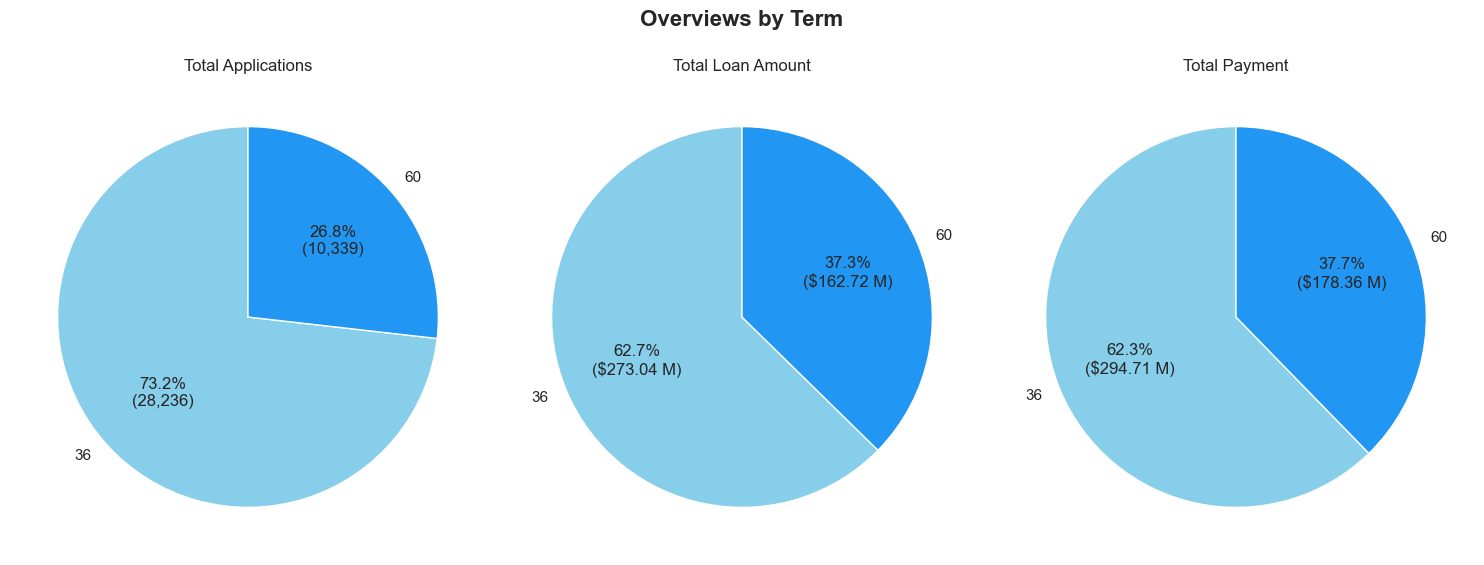

In [94]:
# Set màu sắc
colors = ['skyblue', '#2196F3']

# Tạo biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Overviews by Term', fontsize=16, fontweight='bold')

# Biểu đồ 1: total Applications
total_app = term_data['id']
axes[0].pie(total_app, labels=term_data['term'], autopct=lambda p: f'{p:.1f}%\n({int(p * sum(total_app)/100):,})', colors=colors, startangle=90)
axes[0].set_title('Total Applications')

# Biểu đồ 2: Total Loan Amount
total_loan_amt = term_data['loan_amount']
axes[1].pie(total_loan_amt, labels=term_data['term'], autopct=lambda p: f'{p:.1f}%\n(${p * sum(total_loan_amt)/100:.2f} M)', colors=colors, startangle=90)
axes[1].set_title('Total Loan Amount')

# Biểu đồ 3: Total Payment
total_payment = term_data['total_payment']
axes[2].pie(total_payment, labels=term_data['term'], autopct=lambda p: f'{p:.1f}%\n(${p * sum(total_payment)/100:.2f} M)', colors=colors, startangle=90)
axes[2].set_title('Total Payment')

plt.tight_layout()
plt.show()

##### Conclusion

- **Majority Preference for 36-Month Loans**  
  - **~63.2%** of the total loan amount and **~62.3%** of the total payment are associated with **36-month loans**.
  - **~73.2%** of all loan applications are for 36-month terms, indicating a **clear borrower preference for shorter loan terms**.

- **Longer Terms Have Higher Payment per Loan**  
  - Despite fewer applications (only 26.8%), the **60-month loans still account for a significant 36.8%** of the total loan amount, suggesting that **individual loan sizes may be larger or accumulate more interest**.

- **Risk Management Insight**  
  - The relatively **lower adoption rate of 60-month loans** may reflect **higher perceived risk or repayment burden** over the long term, which can be critical for financial risk assessment.


##### Recommendation:
- Focus marketing and product offerings around **36-month loan terms** due to their popularity, while exploring **risk-adjusted strategies** to encourage uptake of 60-month loans among qualified borrowers.

#### **Overview by Purpose: Total Loan Applications, Total Funded Amount and Total Received Amount**

In [21]:
purpose_data = data.groupby(by='purpose', as_index = False).agg({'loan_amount' : 'sum',
                                     'total_payment':'sum', 'id':'count'
                                     }).sort_values(by='id', ascending=False)
purpose_data

,purpose,loan_amount,total_payment,id
2,Debt Consolidation,232459675.0,253801871.0,18214
1,Credit Card,58885175.0,65214084.0,4998
9,Other,31155750.0,33289676.0,3824
4,Home Improvement,33350775.0,36380930.0,2876
6,Major Purchase,17251600.0,18676927.0,2110
11,Small Business,24123100.0,23814817.0,1776
0,Car,10223575.0,11324914.0,1497
13,Wedding,9225800.0,10266856.0,928
7,Medical,5533225.0,5851372.0,667
8,Moving,3748125.0,3999899.0,559


In [22]:
def convert_to_million(x):
    return round(x/1000000,2)
purpose_data['loan_amount'] = purpose_data['loan_amount'].apply(convert_to_million)
purpose_data['total_payment'] = purpose_data['total_payment'].apply(convert_to_million)
purpose_data

,purpose,loan_amount,total_payment,id
2,Debt Consolidation,232.46,253.80,18214
1,Credit Card,58.89,65.21,4998
9,Other,31.16,33.29,3824
4,Home Improvement,33.35,36.38,2876
6,Major Purchase,17.25,18.68,2110
11,Small Business,24.12,23.81,1776
0,Car,10.22,11.32,1497
13,Wedding,9.23,10.27,928
7,Medical,5.53,5.85,667
8,Moving,3.75,4.00,559


c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: us

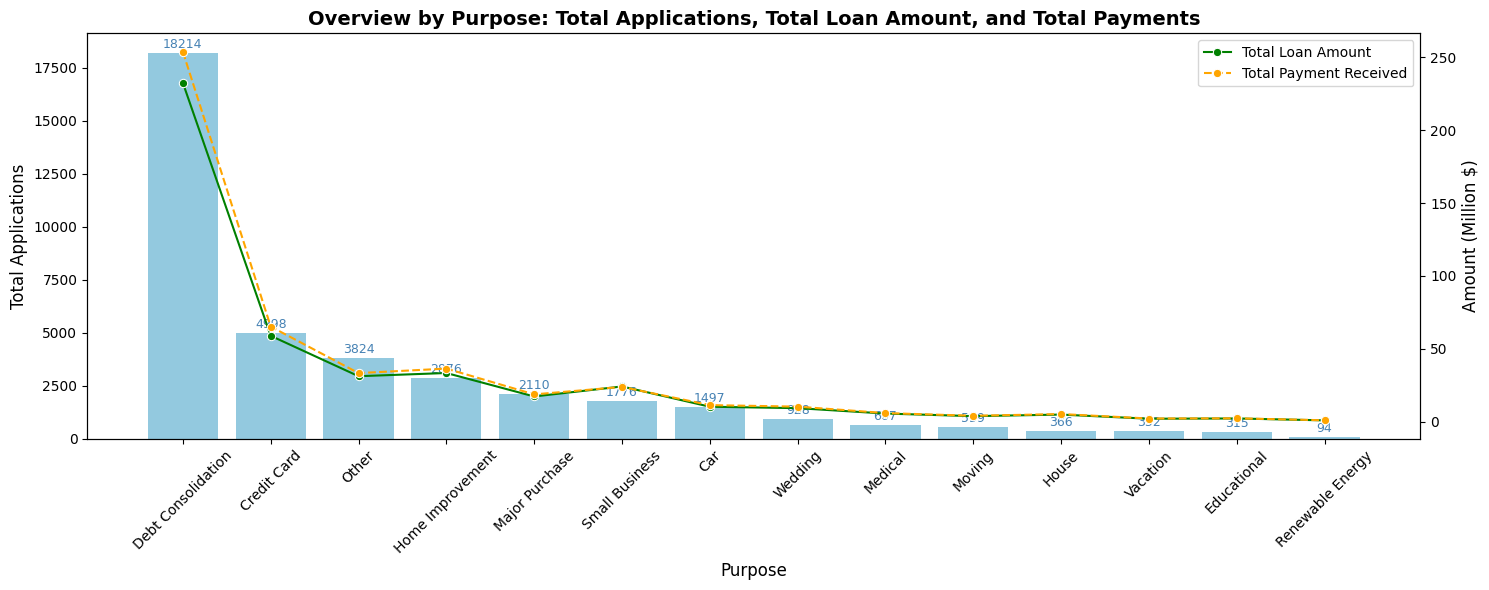

In [52]:
# Plot
fig, ax1 = plt.subplots(figsize=(15, 6))
plt.xticks(rotation=45)

# Bar plot for total applications
sns.barplot(data=purpose_data, x='purpose', y='id', color='skyblue', ax=ax1)
ax1.set_ylabel('Total Applications', fontsize=12)
ax1.set_xlabel('Purpose', fontsize=12)
ax1.tick_params(axis='y')
ax1.set_title('Overview by Purpose: Total Applications, Total Loan Amount, and Total Payments', fontsize=14, fontweight='bold')

# Add values on top of bars
for i, v in enumerate(purpose_data['id']):
    ax1.text(i, v + 100, str(v), ha='center', va='bottom', fontsize=9, color='steelblue')

# Create a second y-axis
ax2 = ax1.twinx()

# Line plots for loan amount and total payment
sns.lineplot(data=purpose_data, x='purpose', y='loan_amount', marker='o', label='Total Loan Amount', color='green', ax=ax2)
sns.lineplot(data=purpose_data, x='purpose', y='total_payment', linestyle='--', marker='o', label='Total Payment Received', color='orange', ax=ax2)
ax2.set_ylabel('Amount (Million $)', fontsize=12)
ax2.tick_params(axis='y')

# Add legends
ax2.legend(loc='upper right')


plt.tight_layout()
plt.show()

##### Conclusion

- **Dominance of Debt-Related Loans**  
  - **Debt Consolidation** is the leading purpose, making up **~58.7%** of total loan amounts and **~60.2%** of total payments, followed by **Credit Card refinancing** with **~14.9%** of loan amount.
  - Combined, debt-related purposes (Debt Consolidation + Credit Card) account for **over 70% of total loan volume**, reflecting borrowers' focus on **managing existing debt**.

- **Secondary but Significant Categories**  
  - **Other**, **Home Improvement**, and **Major Purchase** purposes follow, indicating that consumers also use loans for **personal projects and expenses**, but at a smaller scale.

- **High Risk/Low Return Segments**  
  - **Small Business loans** show relatively **high loan amounts** but **lower total payments**, suggesting **higher risk or lower interest realization**—potentially needing tighter credit policies.

- **Niche Purposes Show Low Demand**  
  - Categories like **Vacation**, **Educational**, and **Renewable Energy** have minimal uptake, indicating either low consumer interest or **limited promotion and availability** of such products.

##### Recommendation
- Prioritize products and marketing around **Debt Consolidation** and **Credit Card refinancing**, as they represent core demand.
- Consider **risk-based pricing or stricter approval** for **Small Business loans**.
- Explore **targeted campaigns** to expand awareness for underused purposes (e.g., Renewable Energy), especially where social/environmental goals align.

#### **Overview by Emp Length: Total Loan Applications, Total Funded Amount and Total Received Amount**

In [28]:
emp_len_data = data.groupby(by='emp_length', as_index = False).agg({'loan_amount' : 'sum',
                                     'total_payment':'sum', 'id':'count'
                                     }).sort_values(by='id', ascending=False)
emp_len_data

,emp_length,loan_amount,total_payment,id
10,10,116115950.0,125871616.0,8870
0,0,44210625.0,47545011.0,4575
2,2,44967975.0,49206961.0,4382
3,3,43937850.0,47551832.0,4088
4,4,37600375.0,40964850.0,3428
5,5,36973625.0,40397571.0,3273
1,1,32883125.0,35498348.0,3229
6,6,25612650.0,27908658.0,2228
7,7,20811725.0,22584136.0,1772
8,8,17558950.0,19025777.0,1476


In [29]:
def convert_to_million(x):
    return round(x/1000000,2)
emp_len_data['loan_amount'] = emp_len_data['loan_amount'].apply(convert_to_million)
emp_len_data['total_payment'] = emp_len_data['total_payment'].apply(convert_to_million)
emp_len_data

,emp_length,loan_amount,total_payment,id
10,10,116.12,125.87,8870
0,0,44.21,47.55,4575
2,2,44.97,49.21,4382
3,3,43.94,47.55,4088
4,4,37.60,40.96,3428
5,5,36.97,40.40,3273
1,1,32.88,35.50,3229
6,6,25.61,27.91,2228
7,7,20.81,22.58,1772
8,8,17.56,19.03,1476


c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: us

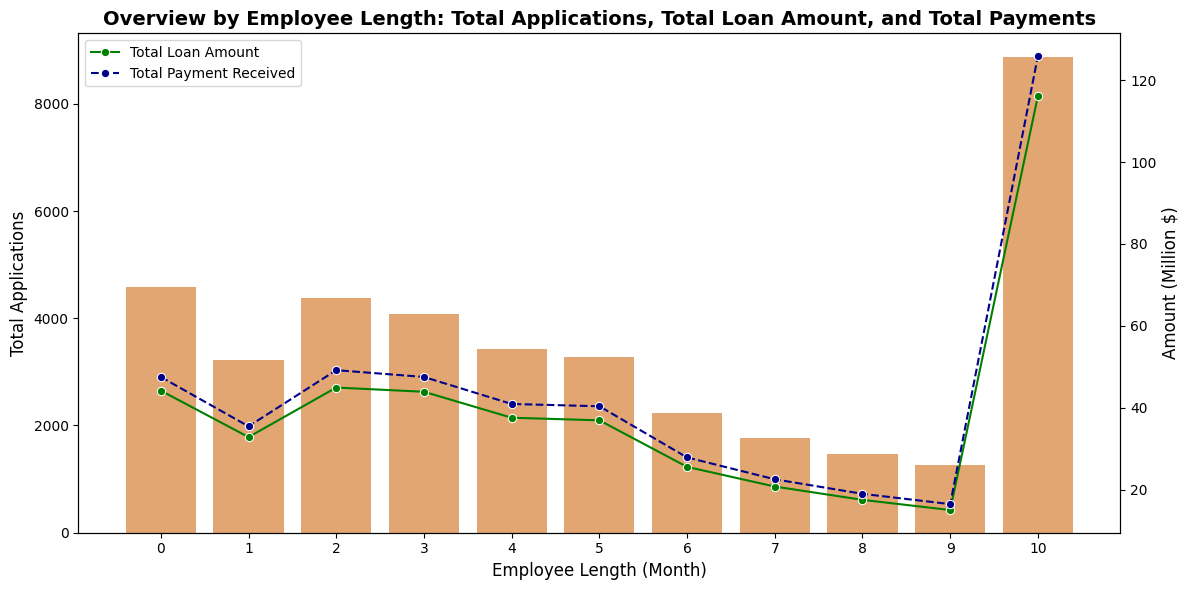

In [62]:
# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for total applications
sns.barplot(data=emp_len_data, x='emp_length', y='id', color='sandybrown', ax=ax1)
ax1.set_ylabel('Total Applications', fontsize=12)
ax1.set_xlabel('Employee Length (Month)', fontsize=12)
ax1.tick_params(axis='y')
ax1.set_title('Overview by Employee Length: Total Applications, Total Loan Amount, and Total Payments', fontsize=14, fontweight='bold')

# Create a second y-axis
ax2 = ax1.twinx()

# Line plots for loan amount and total payment
sns.lineplot(data=emp_len_data, x='emp_length', y='loan_amount', marker='o', label='Total Loan Amount', color='green', ax=ax2)
sns.lineplot(data=emp_len_data, x='emp_length', y='total_payment', linestyle='--', marker='o', label='Total Payment Received', color='darkblue', ax=ax2)
ax2.set_ylabel('Amount (Million $)', fontsize=12)
ax2.tick_params(axis='y')

# Add legends
ax2.legend(loc='upper left')


plt.tight_layout()
plt.show()

##### Conclusion

- **Most Experienced Borrowers Dominate**  
  - Applicants with **10+ years of experience** account for the **highest number of loans (8,870 applications)** and the **largest loan amount ($116M)**, indicating **higher trustworthiness** or **better creditworthiness** among long-term employees.

- **New Entrants Still Active**  
  - Surprisingly, those with **0 years of employment** (possibly new grads or self-employed) make up the **second-largest group** with **4,575 applications**, highlighting a **strong demand among less experienced individuals**, which may require **tighter risk assessment**.

- **Stable Middle Range (2–5 Years)**  
  - Borrowers with **2–5 years of employment** show a **consistently high number of applications (3,200–4,300+)** and **moderate loan volumes**, suggesting this group is a reliable target segment.

- **Lower Demand with 6–9 Years**  
  - There’s a **noticeable drop** in both applications and loan volume for borrowers with **6 to 9 years** of experience, possibly due to **career transitions**, **family planning**, or **other financial responsibilities**.


##### Recommendation
- **Prioritize and expand offerings** for **experienced borrowers (10+ years)** due to strong repayment performance.
- **Enhance credit evaluation for 0–1 year** borrowers using additional risk factors like education, credit score, or co-signers.
- **Explore behavioral trends** in the mid-to-high employment range (6–9 years) to better understand the dip in demand.

#### **Overview by Home Ownership: Total Loan Applications, Total Funded Amount and Total Received Amount**

In [43]:
home_owns_data = data.groupby(by='home_ownership', as_index = False).agg({'loan_amount' : 'sum',
                                     'total_payment':'sum', 'id':'count'
                                     }).sort_values(by='id', ascending=False)
home_owns_data

,home_ownership,loan_amount,total_payment,id
4,RENT,185768475.0,201823056.0,18439
0,MORTGAGE,219329150.0,238474438.0,17198
3,OWN,29597675.0,31729129.0,2838
2,OTHER,1044975.0,1025257.0,98
1,NONE,16800.0,19053.0,3


In [44]:
def convert_to_million(x):
    return round(x/1000000,2)
home_owns_data['loan_amount'] = home_owns_data['loan_amount'].apply(convert_to_million)
home_owns_data['total_payment'] = home_owns_data['total_payment'].apply(convert_to_million)
home_owns_data

,home_ownership,loan_amount,total_payment,id
4,RENT,185.77,201.82,18439
0,MORTGAGE,219.33,238.47,17198
3,OWN,29.60,31.73,2838
2,OTHER,1.04,1.03,98
1,NONE,0.02,0.02,3


c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: us

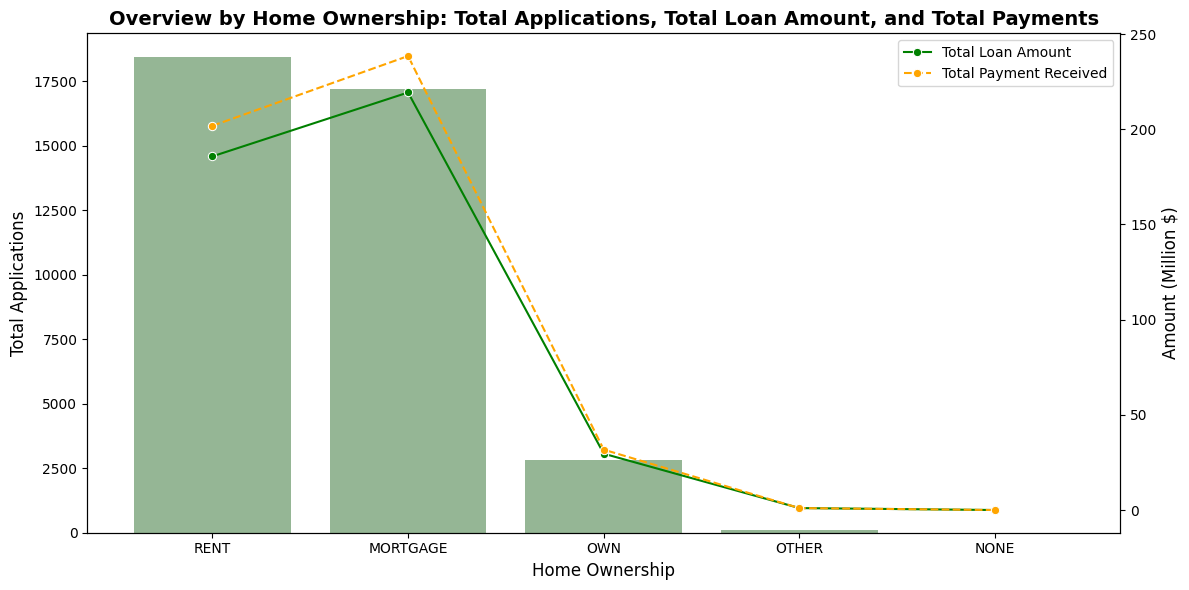

In [65]:
# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for total applications
sns.barplot(data=home_owns_data, x='home_ownership', y='id', color='darkseagreen', ax=ax1)
ax1.set_ylabel('Total Applications', fontsize=12)
ax1.set_xlabel('Home Ownership', fontsize=12)
ax1.tick_params(axis='y')
ax1.set_title('Overview by Home Ownership: Total Applications, Total Loan Amount, and Total Payments', fontsize=14, fontweight='bold')

# Create a second y-axis
ax2 = ax1.twinx()

# Line plots for loan amount and total payment
sns.lineplot(data=home_owns_data, x='home_ownership', y='loan_amount', marker='o', label='Total Loan Amount', color='green', ax=ax2)
sns.lineplot(data=home_owns_data, x='home_ownership', y='total_payment', linestyle='--', marker='o', label='Total Payment Received', color='orange', ax=ax2)
ax2.set_ylabel('Amount (Million $)', fontsize=12)
ax2.tick_params(axis='y')

# Add legends
ax2.legend(loc='upper right')


plt.tight_layout()
plt.show()

##### Conclusion

- **Renters Lead in Loan Applications**  
  - Borrowers who **rent** their homes represent the **largest group**, with **18,439 applications** and total loan amount of **$185.77M**. This suggests renters are **highly active in seeking financial support**, possibly due to **higher living expenses or lack of fixed assets**.

- **Mortgage Holders Borrow More per Person**  
  - While the number of applications from **mortgage holders** is slightly lower (**17,198**), the **total loan amount ($219.33M)** and **total payment ($238.47M)** are the **highest**, indicating that this group tends to **take out larger loans** and may have **higher financial responsibilities** (e.g., home repairs, debt consolidation).

- **Homeowners (OWN) Apply Less, Borrow Conservatively**  
  - Borrowers who **own their homes outright** only make up **2,838 applications**, with a modest loan volume (**$29.6M**). This group likely has **better financial stability**, reducing the need for frequent or large loans.

- **Other & None are Negligible**  
  - Applicants marked as **OTHER** or **NONE** have extremely low volumes and loan amounts, suggesting these are **edge cases** or **data anomalies**.

##### Recommendation

- **Tailor products** for renters and mortgage holders — who form the bulk of the borrower base — with differentiated loan offerings and risk assessments.
- For **renters**, consider offering loans with **flexible terms or lower entry barriers**.
- For **mortgage holders**, provide **larger loan options** with **structured repayment plans**.
- For homeowners, consider **investment or home renovation loans**, as they’re less likely to seek standard consumer lending.

### **"Good Loan" vs "Bad Loan"**

In [66]:
data['loan_status'].unique()

array(['Charged Off', 'Fully Paid', 'Current'], dtype=object)

In [73]:
# data[(data['loan_status'] == 'Fully Paid') | (data['loan_status'] == 'Current')]
loan_status_data = data.groupby(by='loan_status', as_index = False).agg({'loan_amount' : 'sum',
                                     'total_payment':'sum', 'id':'count'
                                     })
loan_status_data

,loan_status,loan_amount,total_payment,id
0,Charged Off,65532225.0,37284763.0,5333
1,Current,18866500.0,24199914.0,1098
2,Fully Paid,351358350.0,411586256.0,32145


In [ ]:
def convert_to_million(x):
    return round(x/1000000,2)
loan_status_data['loan_amount'] = loan_status_data['loan_amount'].apply(convert_to_million)
loan_status_data['total_payment'] = loan_status_data['total_payment'].apply(convert_to_million)

def convert_loan_category(x):
    if x == 'Current':
        return 'Good Loan'
    if x == 'Fully Paid':
        return 'Good Loan'
    else:
        return 'Bad Loan'
loan_status_data['loan_category'] = loan_status_data['loan_status'].apply(convert_loan_category)
loan_status_data

In [77]:
loan_categ_data = loan_status_data.groupby(by='loan_category', as_index = False).agg({'loan_amount' : 'sum',
                                     'total_payment':'sum', 'id':'sum'
                                     })
loan_categ_data

,loan_category,loan_amount,total_payment,id
0,Bad Loan,65.53,37.28,5333
1,Good Loan,370.23,435.79,33243


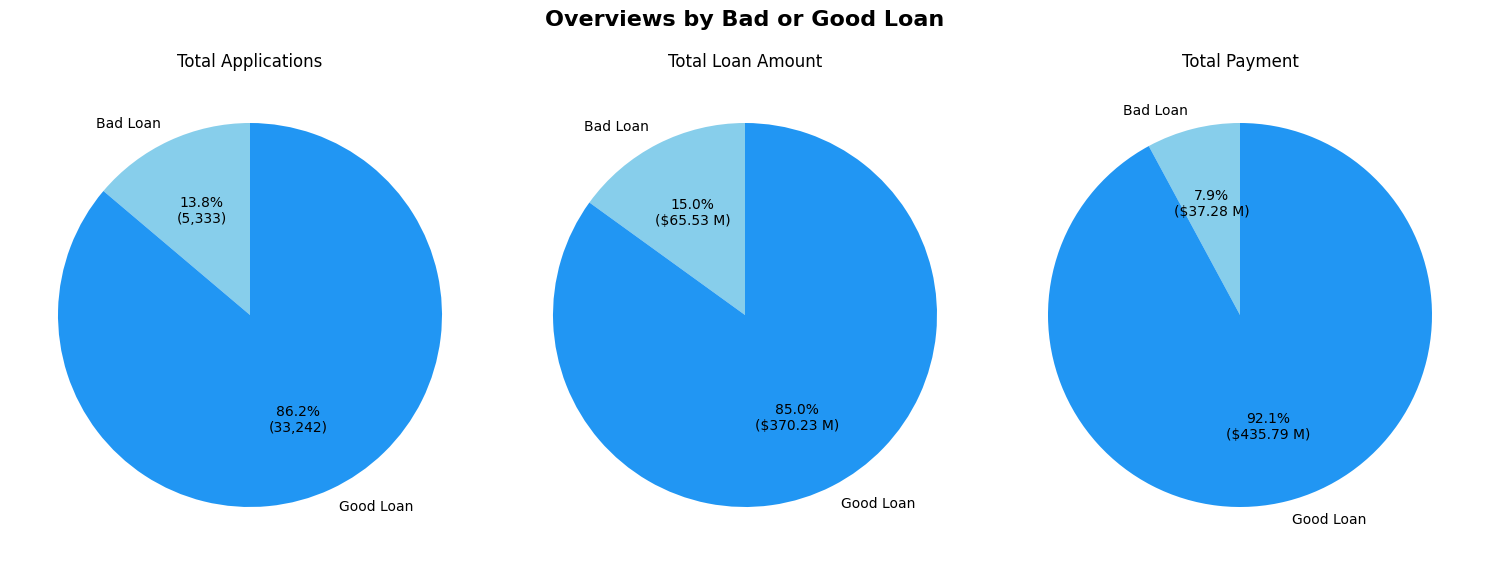

In [78]:
# Set màu sắc
colors = ['skyblue', '#2196F3']

# Tạo biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Overviews by Bad or Good Loan', fontsize=16, fontweight='bold')

# Biểu đồ 1: total Applications
total_app = loan_categ_data['id']
axes[0].pie(total_app, labels=loan_categ_data['loan_category'], autopct=lambda p: f'{p:.1f}%\n({int(p * sum(total_app)/100):,})', colors=colors, startangle=90)
axes[0].set_title('Total Applications')

# Biểu đồ 2: Total Loan Amount
total_loan_amt = loan_categ_data['loan_amount']
axes[1].pie(total_loan_amt, labels=loan_categ_data['loan_category'], autopct=lambda p: f'{p:.1f}%\n(${p * sum(total_loan_amt)/100:.2f} M)', colors=colors, startangle=90)
axes[1].set_title('Total Loan Amount')

# Biểu đồ 3: Total Payment
total_payment = loan_categ_data['total_payment']
axes[2].pie(total_payment, labels=loan_categ_data['loan_category'], autopct=lambda p: f'{p:.1f}%\n(${p * sum(total_payment)/100:.2f} M)', colors=colors, startangle=90)
axes[2].set_title('Total Payment')

plt.tight_layout()
plt.show()

##### **Key Insights**
- **Good Loans dominate** the portfolio:
  - Represent **~85%** of total applications (33,243 out of 38,576).
  - Account for **~85% of total loan amount** and **~92% of total payments received**.
- **Bad Loans**:
  - Make up **~13.8%** of total applications.
  - Generate much **lower repayment** relative to disbursed amount (~**56.9% repayment rate**), indicating higher default or loss.

##### **Conclusion**
The vast majority of loans fall under the **Good Loan** category, which not only contributes most to the revenue but also indicates healthy repayment behavior. However, the presence of Bad Loans—though smaller in number—still reflects potential **risk exposure**. These should be further analyzed for **risk mitigation strategies** and improved **credit risk scoring**.

## **Correlation analysis**

### **DTI & Loan Status**

In [13]:
dti_loan_status_data = data[['dti', 'loan_status']]

def convert_loan_category(x):
    if x == 'Current':
        return 'Good Loan'
    if x == 'Fully Paid':
        return 'Good Loan'
    else:
        return 'Bad Loan'
dti_loan_status_data['loan_status_grouped'] =  dti_loan_status_data['loan_status'].apply(convert_loan_category)
dti_loan_status_data

C:\Users\Acer\AppData\Local\Temp\ipykernel_16928\3378527066.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dti_loan_status_data['loan_status_grouped'] =  dti_loan_status_data['loan_status'].apply(convert_loan_category)


,dti,loan_status,loan_status_grouped
0,0.0100,Charged Off,Bad Loan
1,0.0535,Fully Paid,Good Loan
2,0.2088,Charged Off,Bad Loan
3,0.0540,Fully Paid,Good Loan
4,0.0231,Fully Paid,Good Loan
...,...,...,...
38571,0.1986,Current,Good Loan
38572,0.0458,Current,Good Loan
38573,0.1734,Current,Good Loan
38574,0.0009,Current,Good Loan


<Axes: >

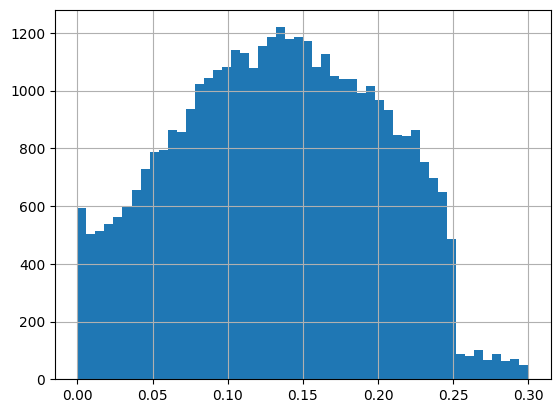

In [14]:
dti_loan_status_data['dti'].hist(bins=50)

<Axes: >

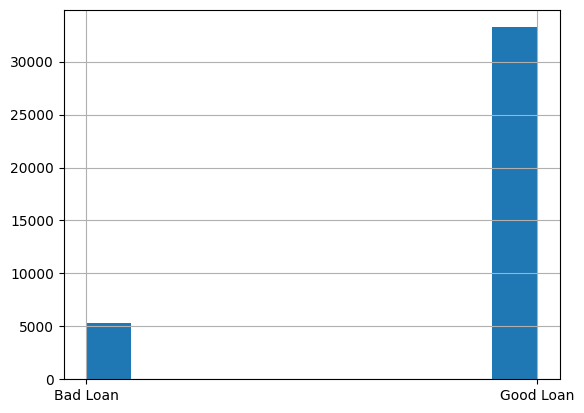

In [15]:
dti_loan_status_data['loan_status_grouped'].hist()

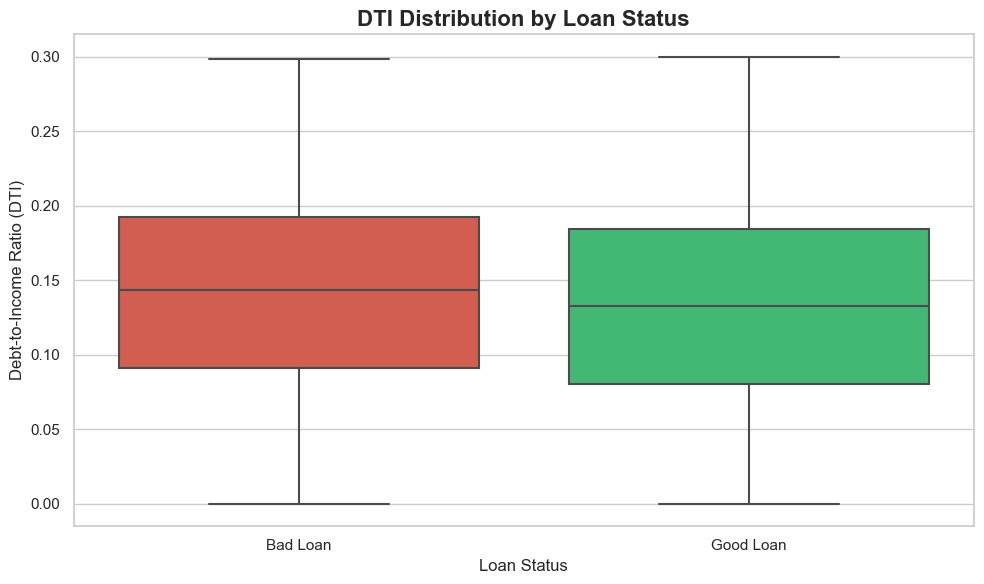

In [22]:
# Set the seaborn style
sns.set_theme(style="whitegrid")

# Plot boxplot to compare DTI by loan status
plt.figure(figsize=(10, 6))
sns.boxplot(data=dti_loan_status_data, x='loan_status_grouped', y='dti', palette={'Good Loan': '#2ecc71', 'Bad Loan': '#e74c3c'})

# Add titles and labels
plt.title('DTI Distribution by Loan Status', fontsize=16, fontweight='bold')
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Debt-to-Income Ratio (DTI)', fontsize=12)

plt.tight_layout()
plt.show()

#### **Conclusion**
- **Median Comparison**:
  - Bad Loan's Median is slightly higher than Good Loan's.
  - This shows that borrowers with bad loans tend to have higher DTI, meaning they pay more debt than their monthly income.
- **Data Distribution (IQR - box plot)**:
  - Both groups have roughly similar distributions, but Bad Loan tends to be more skewed. That is, in the bad loan group, DTI is generally higher than in the good loan group.
- **Outliers**:
  - There are not many outliers, indicating that the DTI distribution in each group is quite even and is not strongly affected by extreme values.
- **Range**:
  - The two groups have roughly similar DTI values ​​(0 to ~0.3).

**Borrowers with bad loans generally have a higher median DTI compared to those with good loans.** This suggests that a higher debt-to-income ratio may be associated with a higher risk of loan default. Managing DTI could be an important factor in improving loan repayment outcomes.

### **Interest Rate & Loan Status**

In [17]:
int_rate_loan_status_data = data[['int_rate', 'loan_status']]

int_rate_loan_status_data['loan_status_grouped'] =  int_rate_loan_status_data['loan_status'].apply(convert_loan_category)
int_rate_loan_status_data

C:\Users\Acer\AppData\Local\Temp\ipykernel_16928\2684613507.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  int_rate_loan_status_data['loan_status_grouped'] =  int_rate_loan_status_data['loan_status'].apply(convert_loan_category)


,int_rate,loan_status,loan_status_grouped
0,0.1527,Charged Off,Bad Loan
1,0.1864,Fully Paid,Good Loan
2,0.1596,Charged Off,Bad Loan
3,0.1065,Fully Paid,Good Loan
4,0.0603,Fully Paid,Good Loan
...,...,...,...
38571,0.1299,Current,Good Loan
38572,0.1349,Current,Good Loan
38573,0.1749,Current,Good Loan
38574,0.1825,Current,Good Loan


<Axes: >

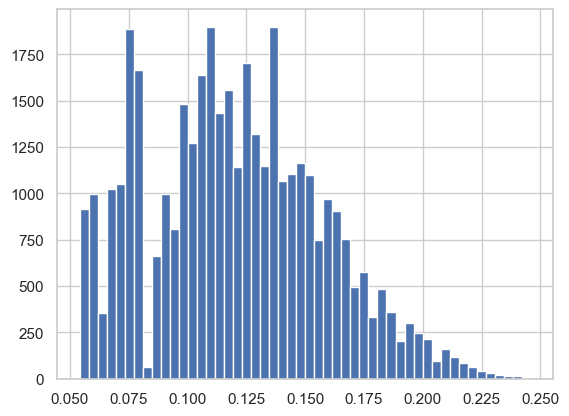

In [19]:
int_rate_loan_status_data['int_rate'].hist(bins=50)

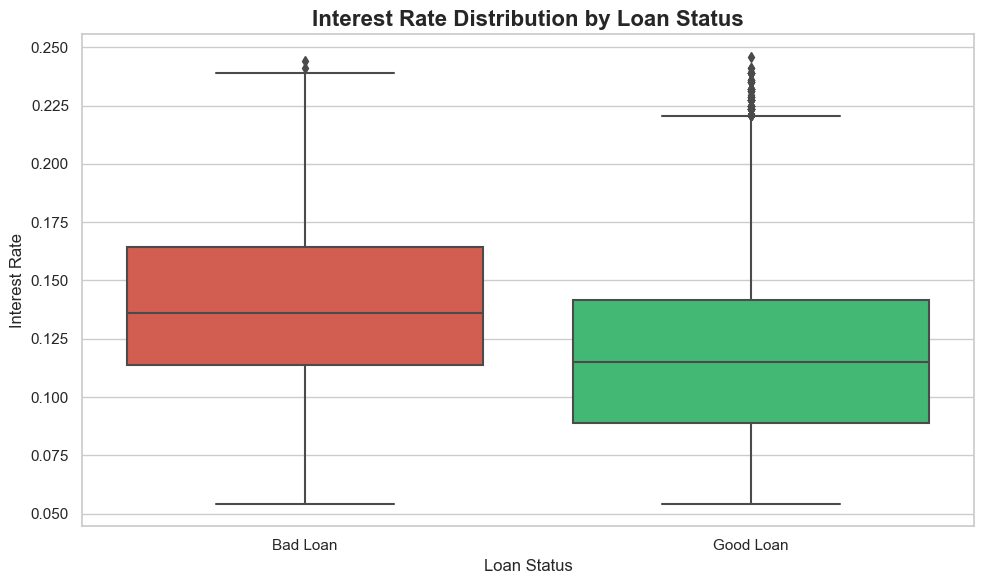

In [23]:
# Set the seaborn style
sns.set_theme(style="whitegrid")

# Plot boxplot to compare Int Rate by loan status
plt.figure(figsize=(10, 6))
sns.boxplot(data=int_rate_loan_status_data, x='loan_status_grouped', y='int_rate', palette={'Good Loan': '#2ecc71', 'Bad Loan': '#e74c3c'})

# Add titles and labels
plt.title('Interest Rate Distribution by Loan Status', fontsize=16, fontweight='bold')
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Interest Rate', fontsize=12)

plt.tight_layout()
plt.show()

#### **Conclusion**
- **Median Comparison**:
  - **Bad Loan** has a higher **median interest rate** than **Good Loan**.
  - This shows that loans with high interest rates are more likely to become bad loans.
- **Data Distribution (IQR - box plot)**:
  - **Bad Loan** có khoảng IQR (Interquartile Range) cao hơn, phần lớn các khoản vay nằm trong vùng lãi suất cao hơn so với Good Loan.
  - **Good Loan** tập trung nhiều hơn ở mức lãi suất thấp.
- **Outliers**:
  - There are many **outliers in Good Loan** in the high interest rate region, but most values ​​are still below 0.15.
  - This shows that some people still repay their loans on time despite high interest rates, but the majority of good loans are associated with low interest rates.
- **Range**:
  - **Bad Loan** trải rộng từ khoảng ~0.05 đến ~0.24, tập trung nhiều ở giữa (~0.13 - 0.17).
  - **Good Loan** nghiêng về phía lãi suất thấp (~0.10 - 0.14), thể hiện chính sách cho vay cẩn trọng hơn hoặc khách hàng có hồ sơ tốt hơn.

**High interest rates tend to be associated with a higher likelihood of default**. Loans with a higher **Interest Rate often result in a Bad Loan**, while **Good Loans often have a lower Interest Rate**, indicating that borrowers with good credit often enjoy preferential interest rates and have a better ability to repay their loans.

### **Annual Income & Loan Status**

In [54]:
income_loan_status_data = data[['annual_income', 'dti', 'loan_status']]

income_loan_status_data['loan_status_grouped'] =  income_loan_status_data['loan_status'].apply(convert_loan_category)

# Đổi income sang K 1000 USD
def convert_income_to_K(x):
    return round((float(x)/1000), 3)

income_loan_status_data['annual_income'] =  income_loan_status_data['annual_income'].apply(convert_income_to_K)

#Focus on annual inncome values from 0 - 1 Millions USD 
income_loan_status_data =  income_loan_status_data[income_loan_status_data['annual_income']<=1000]

income_loan_status_data

C:\Users\Acer\AppData\Local\Temp\ipykernel_16928\3563461547.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  income_loan_status_data['loan_status_grouped'] =  income_loan_status_data['loan_status'].apply(convert_loan_category)
C:\Users\Acer\AppData\Local\Temp\ipykernel_16928\3563461547.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  income_loan_status_data['annual_income'] =  income_loan_status_data['annual_income'].apply(convert_income_to_K)


,annual_income,dti,loan_status,loan_status_grouped
0,30.0,0.0100,Charged Off,Bad Loan
1,48.0,0.0535,Fully Paid,Good Loan
2,50.0,0.2088,Charged Off,Bad Loan
3,42.0,0.0540,Fully Paid,Good Loan
4,83.0,0.0231,Fully Paid,Good Loan
...,...,...,...,...
38571,100.0,0.1986,Current,Good Loan
38572,50.0,0.0458,Current,Good Loan
38573,65.0,0.1734,Current,Good Loan
38574,368.0,0.0009,Current,Good Loan


In [55]:
income_loan_status_data.describe()

,annual_income,dti
count,38562.000000,38562.000000
mean,68.976661,0.133313
std,47.536742,0.066634
min,4.000000,0.000000
25%,41.496000,0.082100
50%,60.000000,0.134200
75%,83.200000,0.185975
max,948.000000,0.299900


<Axes: xlabel='annual_income', ylabel='dti'>

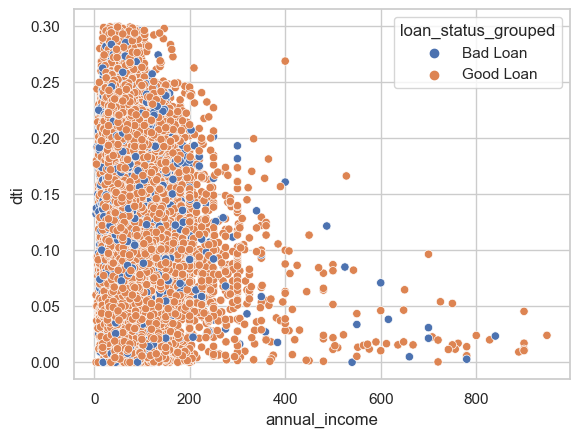

In [56]:
sns.scatterplot(data=income_loan_status_data, x='annual_income', y='dti', hue='loan_status_grouped')

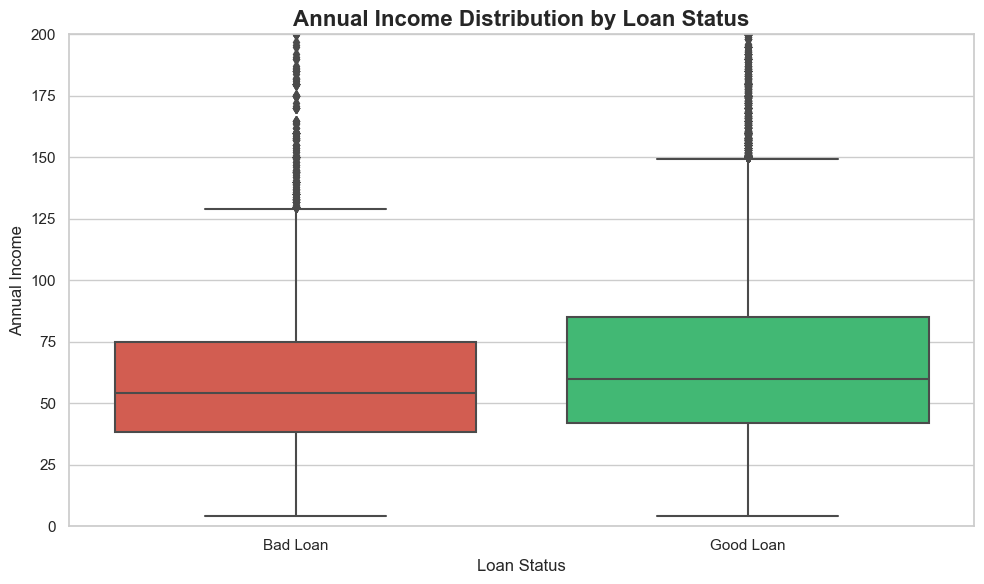

In [ ]:
# Set the seaborn style
sns.set_theme(style="whitegrid")

# Plot boxplot to compare Int Rate by loan status
plt.figure(figsize=(10, 6))
sns.boxplot(data=income_loan_status_data, x='loan_status_grouped', y='annual_income', palette={'Good Loan': '#2ecc71', 'Bad Loan': '#e74c3c'})

#Limited values of Annual Income
plt.ylim(0, 200)

# Add titles and labels
plt.title('Annual Income Distribution by Loan Status', fontsize=16, fontweight='bold')
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Annual Income', fontsize=12)

plt.tight_layout()
plt.show()

(0.0, 200.0)

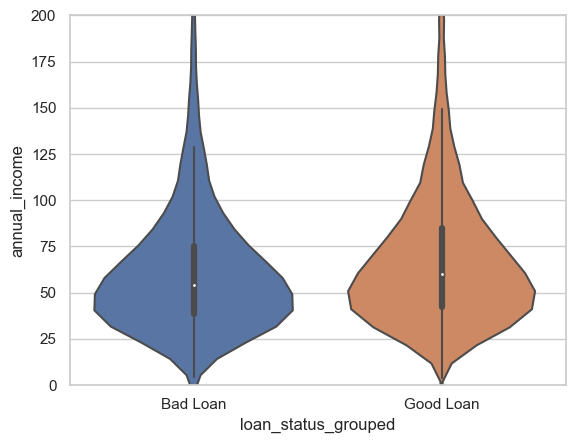

In [63]:
sns.violinplot(data=income_loan_status_data, x='loan_status_grouped', y='annual_income')
plt.ylim(0, 200)

#### **Conclusion**
- **Median Comparison**:
  - The Median of the Good Loan group is higher than the Bad Loan group.
  - This shows that people with higher incomes are generally better able to repay their loans, resulting in a higher “Good Loan” ratio.
- **Data Distribution (IQR - box plot)**:
  - The Good Loan box is longer, indicating a larger IQR range (Q1 to Q3), meaning more diverse income.
  - This group may include both middle and high income earners.
- **Outliers**:
  - Most people with Bad Loans are in the $30k–$75k/year range.
  - There seems to be a correlation between low income and poor debt repayment ability.
- **Range**:
  - Even though we have limited the Y-axis, we still see some data points that are out of the normal range, but the boxplot is no longer "squashed" as before.
  - This makes it easier to see the real differences between the two groups.

**People with higher incomes tend to be Good Loans**, while the Bad Loan group is concentrated in the middle to low income segment.